In [1]:
import numpy as np                        # Μαθηματική/αριθμητική βιβλιοθήκη
import matplotlib.pyplot as plt           # Βιβλιοθήκη απεικονίσεων
%matplotlib inline

## Άσκηση - Προσομοίωση Διαφορικών Εξισώσεων

Οι διαφορικές εξισώσεις περιγράφουν πραγματικά πολλά φυσικά φαινόμενα ή μηχανικές κατασκευές στον πραγματικό κόσμο. Όμως, για να **προσομοιώσουμε** διαφορικές εξισώσεις στον υπολογιστή μας (και να προβλέψουμε πράγματα πριν τα υλοποιήσουμε στην πραγματικότητα), πρέπει να τις "διακριτοποιήσουμε": δεν μπορούμε να αποθηκεύσουμε στον υπολογιστή μας τη συνεχή μεταβλητή $t$ και τις τιμές των συναρτήσεων που εμπλέκονται στη διαφορική εξίσωση. Πρέπει λοιπόν να επιλέξουμε **κάποιες** τιμές για τη μεταβλητή $t$. Φυσικά, η `Python` έχει έτοιμες συναρτήσεις που λύνουν πολύπλοκες διαφορικές εξισώσεις αλλά δε θα μας απασχολήσουν σε αυτήν την άσκηση - δείτε τις υπόλοιπες ασκήσεις του Κεφαλαίου αυτού. Θα ακολουθήσουμε μια πιο απλή και ελέγξιμη προσέγγιση.

Έστω η διαφορική εξίσωση

 $$ \frac{d}{dt}y(t) + 4y(t) = 4x(t) $$

με $y(0^-)=0$, που περιγράφει (π.χ.) ένα κύκλωμα $RC$ (πυκνωτή-αντιστάτη, σαν αυτό που έχει το φλας της φωτογραφικής σας μηχανής ή σαν αυτό που ελέγχει τους υαλοκαθαριστήρες του αυτοκινήτου σας). 

Έχοντας μηδενικές αρχικές συνθήκες, το σύστημά μας είναι ΓΧΑ και η έξοδός του εξαρτάται μόνο από την είσοδο (και φυσικά την κρουστική απόκριση του συστήματος)

Μια απλή μέθοδος διακριτοποίησης της διαφορικής εξίσωσης είναι η **μέθοδος του Euler** (πάλι αυτός???!!! 😁). 

Σκεφτείτε ότι η παράγωγος μιας συνάρτησης $x(t)$ δεν είναι κάτι περισσότερο από το λόγο $\Delta x/ \Delta t$ όταν $\Delta t \rightarrow 0$. Μπορούμε λοιπόν να γράψουμε ότι

\begin{align*}
    \frac{d}{dt}y(t) + 4y(t) &= 4x(t) \\
    \lim_{\Delta t \rightarrow 0} \frac{\Delta y}{\Delta t} + 4y(t) &= 4x(t) \\
    \lim_{h \rightarrow 0}  \frac{y(t+h) - y(t)}{h} + 4y(t) &= 4x(t)
\end{align*}

Παρατηρήστε ότι το $h$ είναι η χρονική διαφορά μεταξύ δύο στιγμών που λαμβάνουμε τιμές για τη συνάρτηση $y(t)$, δηλ. ο αριθμητής του ορίου παραπάνω μας δηλώνει τη διαφορά μεταξύ της $y(t)$ και μιας πολύ πολύ κοντινής της τιμής, της $y(t+h)$, που απέχει χρονικά μόλις $h$ μονάδες χρόνου. Η ελάχιστη μονάδα χρόνου που έχουμε στον "ψηφιακό κόσμο" είναι η *περίοδος δειγματοληψίας* στην προσπάθειά μας να διακριτοποιήσουμε τη διαφορική εξίσωση. Μπορούμε να θέσουμε λοιπόν ως $h=T_s$ (και $t=nT_s, \ n \in \mathbb{N}$), με $T_s$ να είναι η περίοδος δειγματοληψίας. Η τελευταία δεν είναι τίποτε άλλο παρά μια τιμή που καθορίζει κάθε πότε παίρνουμε τιμές από τις συνεχούς χρόνου συναρτήσεις μας. Θέλουμε φυσικά αυτό το $T_s$ να είναι αρκετά μικρό - όσο μικρό επιθυμούμε. Έτσι γράφουμε

\begin{align*}
     \frac{d}{dt}y(t) + 4y(t) =  4x(t) \\
    \lim_{h \rightarrow 0} \frac{y(t+h) - y(t)}{h} + 4y(t) = 4x(t) \\
    \lim_{T_s \rightarrow 0} \frac{y((n+1)T_s) - y(nT_s)}{T_s} + 4y(nT_s) =  4x(nT_s),
\end{align*}

και αν θέλουμε να εκφράσουμε την εξίσωση κατ' ευθείαν στο διακριτό χρόνο, τότε

$$ y((n+1)T_s) = y(nT_s) - 4T_s y(nT_s) + 4T_s x(nT_s)$$

και αναγνωρίζοντας ότι οι χρονικές στιγμές $(n+1)T_s$ και $nT_s$ είναι διαδοχικές τιμές στα διανύσματα διακριτού χρόνου που έχουμε στον υπολογιστή μας (άρα την ποσότητα $T_s$ μπορούμε να την παραλείψουμε όταν εμφανίζεται ως όρισμα των $y(.), x(.)$), μπορούμε να γράψουμε

\begin{equation} 
y(n+1) = y(n) - 4T_s y(n) + 4T_s x(n)
\end{equation}

με $T_s$ πολύ μικρό (αλλά όχι μηδενικό).

Βρήκαμε λοιπόν μια σχέση που διακριτοποιεί τη διαφορική εξίσωση: αντί να έχουμε συναρτήσεις $y(t), x(t)$ έχουμε κάποιες δειγματοληπτημένες εκδόσεις τους, $y(n), x(n)$, δηλ. ένα πεπερασμένο σύνολο από τις τιμές των $y(t), x(t)$. Μπορούμε να γράψουμε κώδικα που για διάφορες τιμές του $T_s$ μας δίνει μια προσέγγιση της λύσης της διαφορικής εξίσωσης. 

Σας δίνεται ότι για είσοδο $x(t)=u(t)$ η θεωρητική λύση της διαφορικής εξίσωσης είναι

$$ y(t) = (1-e^{-4t})u(t) $$

Ο παρακάτω κώδικας εξετάζει πως συμπεριφέρεται η προσέγγισή μας σε σχέση με την τιμή της μεταβλητής $T_s$, ενώ υπολογίζει και το επί τοις εκατό σφάλμα μεταξύ της πραγματικής λύσης και της προσέγγισής μας, σε κάθε χρονική στιγμή $n$:

$$ \mathrm{Error}(n) = \left|\frac {y_\mathrm{approx}(n) -y_\mathrm{true}(n)} {y_\mathrm{true}(n)}\right| \times 100 $$

Ακολουθεί ο κώδικας για $T_s = 0.1$ s. Καλείστε να τον συμπληρώσετε, υπολογίζοντας ρητά κάποιες τιμές της εξόδου $y(n)$ με βάση τη διακριτοποιημένη διαφορική εξίσωση $(1)$ παραπάνω και συγκρίνοντάς τη με τη θεωρητική λύση που σας δίνεται. 

In [2]:
Ts = 0.1                                # Περίοδος δειγματοληψίας
t = np.arange(start=0, stop=2, step=Ts) # Διάνυσμα χρόνου t
x = np.ones(len(t))                     # Eίσοδος x(t) = u(t) (προσεγγιστικά, καθώς το σήμα αυτό διαρκεί μόλις 2 sec και δεν διαρκεί ως το +οο, αλλά είμαστε ΟΚ με αυτό)

# Θεωρητική λύση διαφορικής εξίσωσης όπως σας έχει δοθεί παραπάνω 
# (δε χρειάζεστε την u(t) γιατί το διάνυσμα t ξεκινά από το μηδέν όπως το ορίσαμε μόλις πριν)
y_theory = (1 - np.exp(-4*t))

# Προσεγγιστική λύση
y = np.zeros(len(t))                      # Δέσμευση μνήμης

y[0] = 0                                  # Αρχικοποίηση
for n in range(0, len(y)-1):              # For loop για υλοποίηση εξόδου y(n) διαφορικής εξίσωσης - εξίσωση (1) στην εκφώνηση
    y[n+1] = y[n] - 4*Ts*y[n] + 4*Ts*x[n]

Ας κάνουμε τα γραφήματα της θεωρητικής απάντησης με την προσέγγιση.

C:\Users\kafge\AppData\Local\Temp\ipykernel_8792\781664206.py:12: RuntimeWarning: invalid value encountered in true_divide
  err_pct = np.abs((y - y_theory) / y_theory) * 100


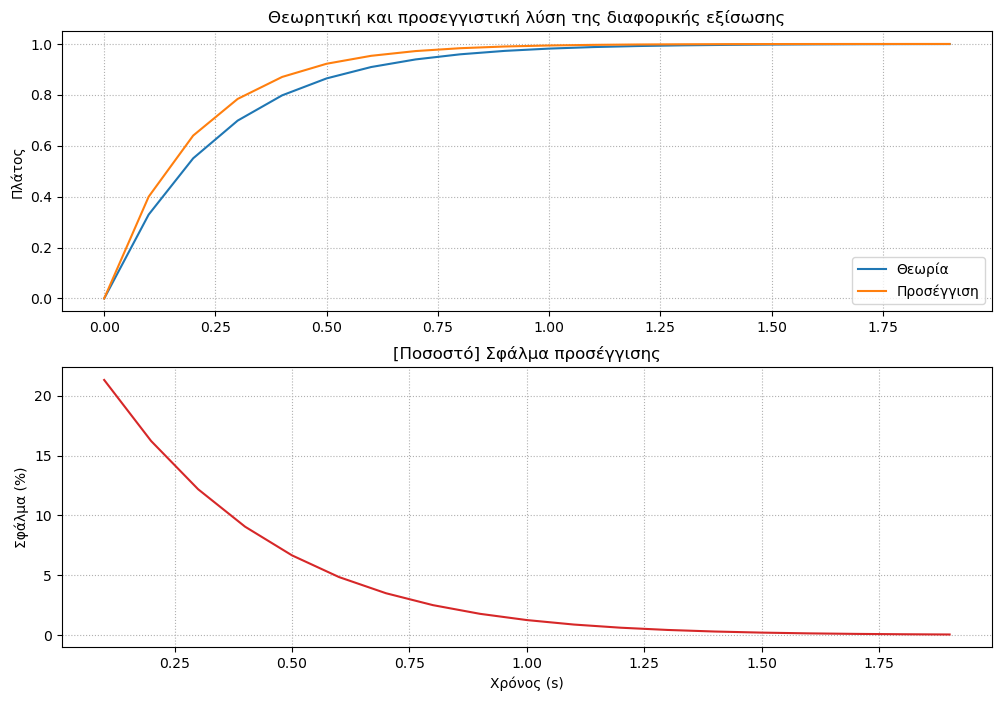

In [3]:
# Γραφήματα
plt.figure(figsize = (12,8))
plt.subplot(2, 1, 1)
plt.plot(t, y_theory ,'-', label="Θεωρία")
plt.plot(t, y, '-', label="Προσέγγιση")
plt.grid(linestyle=':')
plt.title('Θεωρητική και προσεγγιστική λύση της διαφορικής εξίσωσης')
plt.ylabel('Πλάτος')
plt.legend(loc='lower right')

# Υπολογισμός σφάλματος σε ποσοστό επί τοις εκατό (χρησιμοποιήστε την abs()).
err_pct = np.abs((y - y_theory) / y_theory) * 100

plt.subplot(2, 1, 2)
plt.plot(t[:len(t)], err_pct[:len(t)], color='tab:red')
plt.grid(linestyle=':')
plt.title('[Ποσοστό] Σφάλμα προσέγγισης')
plt.xlabel('Χρόνος (s)')
plt.ylabel('Σφάλμα (%)')
plt.show()

Επαναλάβετε το παραπάνω για $T_s = 0.01$ s και τυπώστε τα αντίστοιχα γραφήματα. 

C:\Users\kafge\AppData\Local\Temp\ipykernel_8792\4252499178.py:28: RuntimeWarning: invalid value encountered in true_divide
  err_pct = np.abs((y - y_theory) / y_theory) * 100


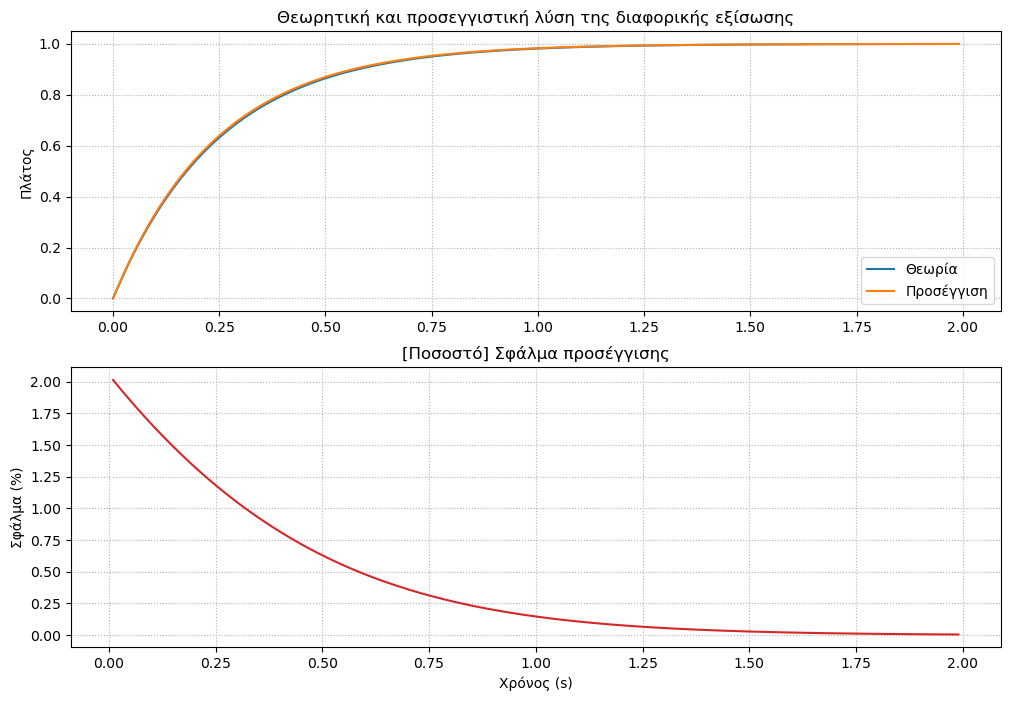

In [4]:
# INSERT CODE HERE
Ts = 0.01                               # Περίοδος δειγματοληψίας
t = np.arange(start=0, stop=2, step=Ts) # Διάνυσμα χρόνου t
x = np.ones(len(t))                     # Eίσοδος x(t) = u(t) (προσεγγιστικά, καθώς το σήμα αυτό διαρκεί μόλις 2 sec και δεν διαρκεί ως το +οο, αλλά είμαστε ΟΚ με αυτό)

# Θεωρητική λύση διαφορικής εξίσωσης όπως σας έχει δοθεί παραπάνω 
# (δε χρειάζεστε την u(t) γιατί το διάνυσμα t ξεκινά από το μηδέν όπως το ορίσαμε μόλις πριν)
y_theory = (1 - np.exp(-4*t))

# Προσεγγιστική λύση
y = np.zeros(len(t))                      # Δέσμευση μνήμης

y[0] = 0                                  # Αρχικοποίηση
for n in range(0, len(y)-1):              # For loop για υλοποίηση εξόδου y(n) διαφορικής εξίσωσης - εξίσωση (1) στην εκφώνηση
    y[n+1] = y[n] - 4*Ts*y[n] + 4*Ts*x[n]

# Γραφήματα
plt.figure(figsize = (12,8))
plt.subplot(2, 1, 1)
plt.plot(t, y_theory ,'-', label="Θεωρία")
plt.plot(t, y, '-', label="Προσέγγιση")
plt.grid(linestyle=':')
plt.title('Θεωρητική και προσεγγιστική λύση της διαφορικής εξίσωσης')
plt.ylabel('Πλάτος')
plt.legend(loc='lower right')

# Υπολογισμός σφάλματος σε ποσοστό επί τοις εκατό (χρησιμοποιήστε την abs()).
err_pct = np.abs((y - y_theory) / y_theory) * 100

plt.subplot(2, 1, 2)
plt.plot(t[:len(t)], err_pct[:len(t)], color='tab:red')
plt.grid(linestyle=':')
plt.title('[Ποσοστό] Σφάλμα προσέγγισης')
plt.xlabel('Χρόνος (s)')
plt.ylabel('Σφάλμα (%)')
plt.show()

# END OF CODE

Τι παρατηρείτε για την προσέγγιση της εξόδου όσον αφορά τις δυο διαφορετικές τιμές της παραμέτρου $T_s$? Γράψτε την απάντησή σας σε αυτό το κελί:

### Απάντηση:

Όσο μικραίνει η μεταβλητή $T_s$ τόσο πιο καλή προσέγγιση της λύσης της διαφορικής εξίσωσης έχουμε.

---
---